# Data Preprocessing 
Load raw data, visualize, map labels, chunk windows, and normalize.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('d:/Swin documents/COS40007-Project/backend')

# Importing libraries

In [2]:
from types import SimpleNamespace
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from utils.seed import set_seed
from utils.device import get_device
from data.preprocessing import (
    create_windows,
    clean_features,
    get_feature_columns,
 )
from data.motion_dataset import MotionDataset

# Config (no Hydra)
seed = 42
device = get_device("auto")
set_seed(seed)

sensor_types = ["Segment Position"]
video_suffix = None
window_size = 60
stride = 30
batch_size = 32
num_workers = 0
val_split = 0.2


# Read data 

In [3]:
print("[phase=data] loading P1 + P2 segment_position datasets")
DATA_DIR = PROJECT_ROOT / "output_data"

# P1 source
p1_dfs = [
    pd.read_csv(DATA_DIR / "P1_boning_segment_position.csv"),
    pd.read_csv(DATA_DIR / "P1_slicing_segment_position.csv"),
]
p1_raw_df = pd.concat(p1_dfs, ignore_index=True)

# P2 source
p2_dfs = [
    pd.read_csv(DATA_DIR / "P2_boning_segment_position.csv"),
    pd.read_csv(DATA_DIR / "P2_slicing_segment_position.csv"),
]
p2_raw_df = pd.concat(p2_dfs, ignore_index=True)

# Keep segment-position rows only
if "sensor_type" in p1_raw_df.columns:
    p1_raw_df = p1_raw_df[p1_raw_df["sensor_type"].isin(sensor_types)]
if "sensor_type" in p2_raw_df.columns:
    p2_raw_df = p2_raw_df[p2_raw_df["sensor_type"].isin(sensor_types)]

# Optional video suffix filter
if video_suffix is not None:
    p1_raw_df = p1_raw_df[p1_raw_df["video_id"].str.endswith(video_suffix)]
    p2_raw_df = p2_raw_df[p2_raw_df["video_id"].str.endswith(video_suffix)]

def derive_velocity_and_acceleration_from_position(df):
    if df.empty:
        raise ValueError("Input dataframe is empty.")

    base_feature_cols = get_feature_columns(df)

    id_cols = [
        c for c in ["video_id", "Frame", "Label", "person_id", "activity_type", "knife_sharpness_score"]
        if c in df.columns
    ]

    work_df = df[id_cols + base_feature_cols].copy()
    work_df = work_df.sort_values(["video_id", "Frame"]).reset_index(drop=True)

    frame_delta = work_df.groupby("video_id")["Frame"].diff().astype(float)
    frame_delta = frame_delta.replace(0, np.nan).fillna(1.0)

    for col in base_feature_cols:
        vel_col = f"{col}_vel"
        acc_col = f"{col}_acc"

        pos_diff = work_df.groupby("video_id")[col].diff().fillna(0.0)
        work_df[vel_col] = pos_diff / frame_delta

        vel_diff = work_df.groupby("video_id")[vel_col].diff().fillna(0.0)
        work_df[acc_col] = vel_diff / frame_delta

    velocity_feature_cols = [f"{c}_vel" for c in base_feature_cols]
    acceleration_feature_cols = [f"{c}_acc" for c in base_feature_cols]

    derived_df = work_df[id_cols + velocity_feature_cols + acceleration_feature_cols]
    return derived_df, base_feature_cols

p1_df, base_feature_cols = derive_velocity_and_acceleration_from_position(p1_raw_df)
p2_df, _ = derive_velocity_and_acceleration_from_position(p2_raw_df)

velocity_feature_cols = [f"{c}_vel" for c in base_feature_cols]
acceleration_feature_cols = [f"{c}_acc" for c in base_feature_cols]
feature_cols = velocity_feature_cols + acceleration_feature_cols

assert p1_df["Label"].nunique() > 1, "Only one class left after filtering - train/val invalid"
assert p2_df["Label"].nunique() > 1, "Only one class left after filtering - test invalid"

print(f"[phase=data] p1_rows={len(p1_df)} p2_rows={len(p2_df)}")
print(f"[phase=data] velocity_features={len(velocity_feature_cols)} acceleration_features={len(acceleration_feature_cols)} total_features={len(feature_cols)}")
p1_df.head()


[phase=data] loading P1 + P2 segment_position datasets


C:\Users\PCPV\AppData\Local\Temp\ipykernel_10208\3974127056.py:7: DtypeWarning: Columns (70) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(DATA_DIR / "P1_slicing_segment_position.csv"),
C:\Users\PCPV\AppData\Local\Temp\ipykernel_10208\3974127056.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  work_df[acc_col] = vel_diff / frame_delta
C:\Users\PCPV\AppData\Local\Temp\ipykernel_10208\3974127056.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  work_df[vel_col] = pos_diff / frame_de

[phase=data] p1_rows=266924 p2_rows=263369
[phase=data] velocity_features=66 acceleration_features=66 total_features=132


C:\Users\PCPV\AppData\Local\Temp\ipykernel_10208\3974127056.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  work_df[acc_col] = vel_diff / frame_delta


,video_id,Frame,Label,person_id,activity_type,knife_sharpness_score,L5 x_vel,L5 y_vel,L5 z_vel,L3 x_vel,...,Left Upper Leg z_acc,Left Lower Leg x_acc,Left Lower Leg y_acc,Left Lower Leg z_acc,Left Foot x_acc,Left Foot y_acc,Left Foot z_acc,Left Toe x_acc,Left Toe y_acc,Left Toe z_acc
0,MVN-J-Boning-64-001,0,4,P1,boning,64,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
1,MVN-J-Boning-64-001,1,4,P1,boning,64,0.000019,0.000018,0.000003,-0.000367,...,-2.370342e-04,-6.575109e-04,-0.001364,-2.911292e-04,6.573168e-04,-1.852091e-04,-0.000276,2.383122e-04,-0.000198,-4.197929e-05
2,MVN-J-Boning-64-001,2,4,P1,boning,64,0.000019,0.000018,0.000003,-0.000367,...,-2.220446e-16,1.110223e-16,0.000000,-1.110223e-16,-3.469447e-18,-8.326673e-17,0.000000,-1.387779e-17,0.000000,-9.714451e-16
3,MVN-J-Boning-64-001,3,4,P1,boning,64,0.000058,-0.000044,-0.000008,-0.000305,...,-3.261838e-05,3.043750e-04,0.000020,-1.203276e-05,-3.124947e-04,1.391430e-05,-0.000078,-2.681256e-04,0.000042,-2.587817e-05
4,MVN-J-Boning-64-001,4,4,P1,boning,64,0.000106,-0.000145,-0.000026,-0.000233,...,-6.432043e-05,5.022880e-04,0.000025,-3.048290e-05,-5.128256e-04,3.073590e-05,-0.000142,-4.484014e-04,0.000081,-4.093058e-05


# Visualize Data (Optional)

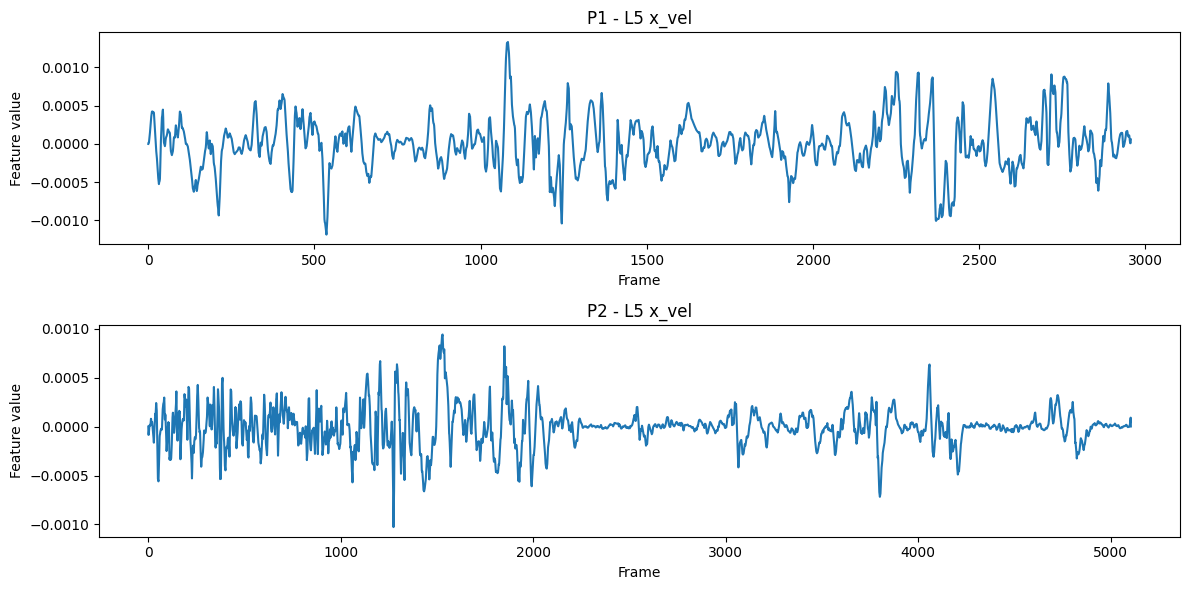

In [4]:
import matplotlib.pyplot as plt

# choose feature to visualize
feature_name = "L5 x_vel"   # change to any feature column

# optionally select one video from each dataset
p1_sample = p1_df[p1_df["video_id"] == p1_df["video_id"].iloc[0]]
p2_sample = p2_df[p2_df["video_id"] == p2_df["video_id"].iloc[0]]

# frame index
x1 = range(len(p1_sample))
x2 = range(len(p2_sample))

# create horizontal stacked plots
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# P1 plot
axes[0].plot(x1, p1_sample[feature_name])
axes[0].set_title(f"P1 - {feature_name}")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Feature value")

# P2 plot
axes[1].plot(x2, p2_sample[feature_name])
axes[1].set_title(f"P2 - {feature_name}")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Feature value")

plt.tight_layout()
plt.show()

# Process Data: Split Train/Test/Val

In [5]:
import pandas as pd

print("[phase=data] Unique labels and their counts per activity:")

# 1. Combine both datasets to get the overall count
combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

# 2. Group by activity_type and Label to calculate counts
overall_label_counts = combined_df.groupby(
    ['Label']
).size().reset_index(name='Count')

# 3. Print the detailed breakdown
print(overall_label_counts.to_string(index=False))


[phase=data] Unique labels and their counts per activity:
                    Label  Count
                        0  62957
                        1  14608
                        2  47603
                        3  20293
                        4 237839
                        5  53089
                        6   7315
                        7   7685
                        8  18913
                      0.0   1394
                      1.0     60
             2 - Steeling   1469
                      2.0    248
             3 - Reaching   3282
              4 - Cutting  24550
                      4.0   2298
              5 - Slicing  18779
                      5.0    760
7 - Placing/ Manipulating    787
             8 - Dropping   5854
                      8.0    510


# Relabel

In [6]:
print("[phase=data] Cleaning inconsistent labels")

label_mapping = {
    '0- Idle': 0,
    '0 - Idle': 0,
    '1- Walking': 1,
    '1 - Walking': 1,
    '2- Steeling': 2,
    '2 - Steeling': 2,
    '3- Reaching': 3,
    '3 - Reaching': 3,
    '4- Cutting': 4,
    '4 - Cutting': 4,
    '4 - Cutting (Big Pieces)': 4,
    '4 - Cutting (Big Piece)': 4,
    '4- Cutting (big piece)': 4,
    '4 - Cutting (offloading bone from Carcass)': 4,
    '5- Dropping': 8,
    '5 - Dropping': 8,
    '5 - Slicing': 5,
    '6 - Pulling': 6,
    '7 - Placing/ Manipulating': 7,
    '8 - Dropping': 8,
}

p1_df['Label'] = p1_df['Label'].replace(label_mapping)
p2_df['Label'] = p2_df['Label'].replace(label_mapping)

for df in [p1_df, p2_df]:
    df['Label'] = pd.to_numeric(df['Label'], errors='coerce')

for df in [p1_df, p2_df]:
    boning_mask = df['activity_type'].str.lower().eq('boning')
    df.loc[boning_mask & (df['Label'] == 5), 'Label'] = 8

for df in [p1_df, p2_df]:
    if df['Label'].isna().any():
        print("[warning] Found non-numeric labels after mapping")
    df['Label'] = df['Label'].astype('int64')

combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

print("[phase=data] Unique video_id values after relabel:")
unique_video_ids = sorted(combined_df['video_id'].dropna().astype(str).unique().tolist())
print(f"total_video_ids={len(unique_video_ids)}")
for video_id in unique_video_ids:
    print(video_id)

overall_label_counts = combined_df.groupby(['activity_type', 'Label']).size().reset_index(name='Count')
print("\n[phase=data] label counts by activity:")
print(overall_label_counts.to_string(index=False))

[phase=data] Cleaning inconsistent labels
[phase=data] Unique video_id values after relabel:
total_video_ids=26
MVN-J-Boning-64-001
MVN-J-Boning-64-002
MVN-J-Boning-64-003
MVN-J-Boning-64-004
MVN-J-Boning-64-005
MVN-J-Boning-64-006
MVN-J-Boning-79-001
MVN-J-Boning-90-001
MVN-J-Boning-90-002
MVN-J-Boning-90-003
MVN-J-Boning-90-004
MVN-J-Slicing-64-001
MVN-J-Slicing-73-001
MVN-J-Slicing-87-001
MVN-S-Boning-63-001
MVN-S-Boning-63-002
MVN-S-Boning-63-003
MVN-S-Boning-76-001
MVN-S-Boning-76-002
MVN-S-Boning-89-001
MVN-S-Boning-89-002
MVN-S-Boning-89-003
MVN-S-Boning-89-004
MVN-S-Slicing-63-001
MVN-S-Slicing-73-001
MVN-S-Slicing-87-001

[phase=data] label counts by activity:
activity_type  Label  Count
       boning      0  54101
       boning      1  13218
       boning      2  36588
       boning      3  11699
       boning      4 151989
       boning      8  11534
      slicing      0  10250
      slicing      1   1450
      slicing      2  12732
      slicing      3  11876
      slicing 

# Feature Engineering

In [7]:
import numpy as np
import pandas as pd

combined_df = pd.concat([p1_df, p2_df], ignore_index=True)

# Build segment list from base xyz feature names (e.g., "L5 x")
segment_names = []
for col in base_feature_cols:
    segment_name, axis = col.rsplit(" ", 1)
    if axis == "x":
        segment_names.append(segment_name)

# 22 velocity magnitude features + 22 acceleration magnitude features
for seg in segment_names:
    vx_col, vy_col, vz_col = f"{seg} x_vel", f"{seg} y_vel", f"{seg} z_vel"
    ax_col, ay_col, az_col = f"{seg} x_acc", f"{seg} y_acc", f"{seg} z_acc"

    vel_mag_col = f"{seg}_vel_mag"
    acc_mag_col = f"{seg}_acc_mag"

    combined_df[vel_mag_col] = np.sqrt(
        combined_df[vx_col] ** 2 + combined_df[vy_col] ** 2 + combined_df[vz_col] ** 2
    )
    combined_df[acc_mag_col] = np.sqrt(
        combined_df[ax_col] ** 2 + combined_df[ay_col] ** 2 + combined_df[az_col] ** 2
    )

velocity_mag_feature_cols = [f"{seg}_vel_mag" for seg in segment_names]
acceleration_mag_feature_cols = [f"{seg}_acc_mag" for seg in segment_names]

# 1 total body energy feature: sum of squared x,y,z over all joints (velocity + acceleration)
energy_terms = []
for seg in segment_names:
    energy_terms.extend([
        combined_df[f"{seg} x_vel"] ** 2,
        combined_df[f"{seg} y_vel"] ** 2,
        combined_df[f"{seg} z_vel"] ** 2,
        combined_df[f"{seg} x_acc"] ** 2,
        combined_df[f"{seg} y_acc"] ** 2,
        combined_df[f"{seg} z_acc"] ** 2,
    ])
combined_df["total_body_energy"] = np.sum(np.column_stack(energy_terms), axis=1)

# Final training features: 22 + 22 + 1 = 45
feature_cols = velocity_mag_feature_cols + acceleration_mag_feature_cols + ["total_body_energy"]

print("[phase=features] Using engineered features by request")
print(f"Velocity magnitude features: {len(velocity_mag_feature_cols)}")
print(f"Acceleration magnitude features: {len(acceleration_mag_feature_cols)}")
print("Total body energy features: 1")
print(f"Total training features: {len(feature_cols)}")
print("Sample features:", feature_cols[:5], "...", feature_cols[-3:])

C:\Users\PCPV\AppData\Local\Temp\ipykernel_10208\4210890001.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df[vel_mag_col] = np.sqrt(
C:\Users\PCPV\AppData\Local\Temp\ipykernel_10208\4210890001.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df[acc_mag_col] = np.sqrt(
C:\Users\PCPV\AppData\Local\Temp\ipykernel_10208\4210890001.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

[phase=features] Using engineered features by request
Velocity magnitude features: 22
Acceleration magnitude features: 22
Total body energy features: 1
Total training features: 45
Sample features: ['L5_vel_mag', 'L3_vel_mag', 'T12_vel_mag', 'T8_vel_mag', 'Neck_vel_mag'] ... ['Left Foot_acc_mag', 'Left Toe_acc_mag', 'total_body_energy']


C:\Users\PCPV\AppData\Local\Temp\ipykernel_10208\4210890001.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df["total_body_energy"] = np.sum(np.column_stack(energy_terms), axis=1)


In [8]:
print(p1_df["Label"].dtype)

int64


# Dynamic Windows by Label Transitions

Detect activity label changes (without groupby), count frames per label, visualize one sample, then build dynamic windows.

In [9]:
import pandas as pd

print("[phase=runs] Building contiguous label runs by video_id + label change (no groupby)")

combined_df = combined_df.sort_values(["video_id", "Frame"]).reset_index(drop=True)

runs = []
frame_counts = {}
run_counts = {}

start_idx = 0
current_video = combined_df.loc[0, "video_id"]
current_label = int(combined_df.loc[0, "Label"])

for i in range(len(combined_df)):
    label_i = int(combined_df.loc[i, "Label"])
    frame_counts[label_i] = frame_counts.get(label_i, 0) + 1

for i in range(1, len(combined_df)):
    video_i = combined_df.loc[i, "video_id"]
    label_i = int(combined_df.loc[i, "Label"])

    is_boundary = (video_i != current_video) or (label_i != current_label)

    if is_boundary:
        end_idx = i - 1
        start_frame = int(combined_df.loc[start_idx, "Frame"])
        end_frame = int(combined_df.loc[end_idx, "Frame"])
        run_length = end_idx - start_idx + 1

        runs.append({
            "video_id": current_video,
            "label": current_label,
            "start_idx": start_idx,
            "end_idx": end_idx,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "run_length": run_length,
        })

        run_counts[current_label] = run_counts.get(current_label, 0) + 1

        start_idx = i
        current_video = video_i
        current_label = label_i

end_idx = len(combined_df) - 1
start_frame = int(combined_df.loc[start_idx, "Frame"])
end_frame = int(combined_df.loc[end_idx, "Frame"])
run_length = end_idx - start_idx + 1
runs.append({
    "video_id": current_video,
    "label": current_label,
    "start_idx": start_idx,
    "end_idx": end_idx,
    "start_frame": start_frame,
    "end_frame": end_frame,
    "run_length": run_length,
})
run_counts[current_label] = run_counts.get(current_label, 0) + 1

print(f"[phase=runs] total_runs={len(runs)}")
print("[phase=runs] frame count per label:")
for label in sorted(frame_counts):
    print(f"  label {label}: {frame_counts[label]}")

print("[phase=runs] run count per label:")
for label in sorted(run_counts):
    print(f"  label {label}: {run_counts[label]}")

runs_df = pd.DataFrame(runs)
print("[phase=runs] run length stats:")
print(runs_df['run_length'].describe(percentiles=[0.5]).to_string())

[phase=runs] Building contiguous label runs by video_id + label change (no groupby)
[phase=runs] total_runs=1263
[phase=runs] frame count per label:
  label 0: 64351
  label 1: 14668
  label 2: 49320
  label 3: 23575
  label 4: 264687
  label 5: 61094
  label 6: 7315
  label 7: 8472
  label 8: 36811
[phase=runs] run count per label:
  label 0: 130
  label 1: 61
  label 2: 104
  label 3: 172
  label 4: 338
  label 5: 91
  label 6: 22
  label 7: 88
  label 8: 257
[phase=runs] run length stats:
count    1263.000000
mean      419.867775
std       510.592815
min        18.000000
50%       210.000000
max      4737.000000


[phase=plot] Plotting one sample video with label transitions
[phase=plot] Sample video: MVN-J-Boning-64-001 (2957 frames)


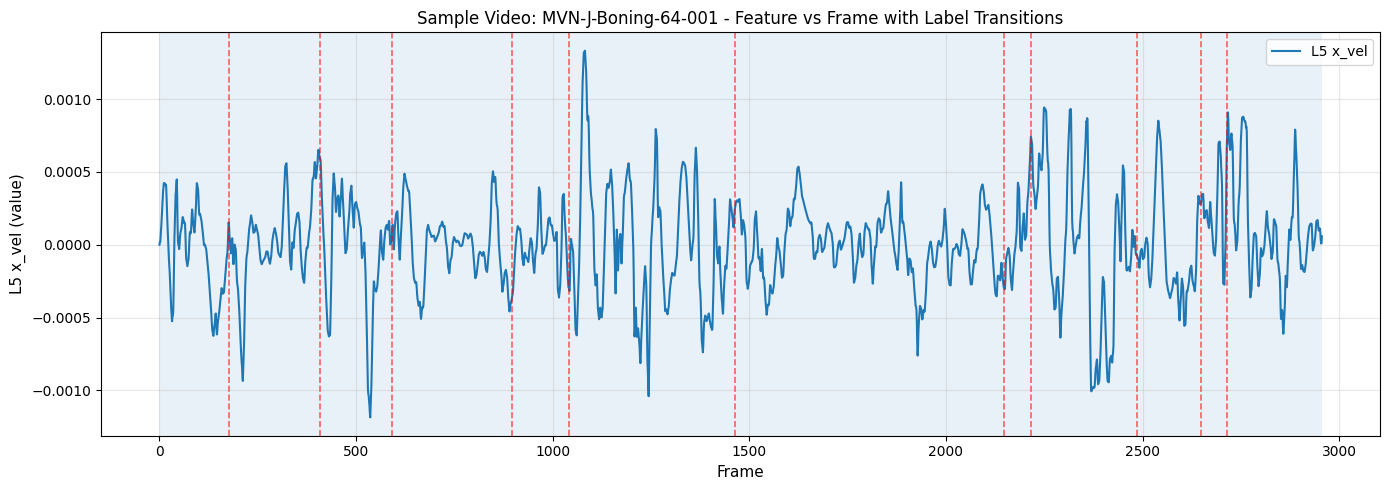

[phase=plot] Red dashed lines indicate label transition points.


In [10]:
import matplotlib.pyplot as plt

print("[phase=plot] Plotting one sample video with label transitions")

# Select first unique video from combined_df
sample_video_id = combined_df["video_id"].unique()[0]
sample_df = combined_df[combined_df["video_id"] == sample_video_id].copy()
sample_df = sample_df.sort_values("Frame").reset_index(drop=True)

print(f"[phase=plot] Sample video: {sample_video_id} ({len(sample_df)} frames)")

# Plot setup
feature_name = "L5 x_vel"  # Choose a sample feature to visualize
fig, ax = plt.subplots(figsize=(14, 5))

# Plot feature value vs Frame
frames = sample_df["Frame"].values
feature_values = sample_df[feature_name].values
ax.plot(frames, feature_values, linewidth=1.5, label=feature_name)

# Mark transition boundaries
transitions = sample_df[sample_df["Label"].diff().fillna(0) != 0]["Frame"].values
for t_frame in transitions:
    ax.axvline(x=t_frame, color='red', linestyle='--', alpha=0.6, linewidth=1.2)

# Shade regions by label
previous_transition = frames[0]
for t_frame in transitions:
    ax.axvspan(previous_transition, t_frame, alpha=0.1)
    previous_transition = t_frame
ax.axvspan(previous_transition, frames[-1], alpha=0.1)

ax.set_xlabel("Frame", fontsize=11)
ax.set_ylabel(f"{feature_name} (value)", fontsize=11)
ax.set_title(f"Sample Video: {sample_video_id} - Feature vs Frame with Label Transitions", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"[phase=plot] Red dashed lines indicate label transition points.")


# Normalize Data


In [11]:
# Normalize data (frame-level) using train frames only
from sklearn.preprocessing import StandardScaler

# Hold-out specific videos for validation (to avoid leakage)
TEST_VIDEO_IDS = ["MVN-J-Boning-90-004", "MVN-S-Slicing-63-001","MVN-S-Boning-89-004"]

# Split by video_id
train_df = combined_df[~combined_df["video_id"].isin(TEST_VIDEO_IDS)].copy()
val_df = combined_df[combined_df["video_id"].isin(TEST_VIDEO_IDS)].copy()

# Fit scaler on train frames only
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])

print("[phase=norm] StandardScaler fit on train frames only")
print("Train stats -> min:", train_df[feature_cols].min().min(),
      "max:", train_df[feature_cols].max().max(),
      "mean:", train_df[feature_cols].mean().mean(),
      "std:", train_df[feature_cols].std().mean())
# print("Val   stats -> min:", val_df[feature_cols].min().min(),
#       "max:", val_df[feature_cols].max().max(),
#       "mean:", val_df[feature_cols].mean().mean(),
#       "std:", val_df[feature_cols].std().mean())


print("[phase=norm] Train per-column min/max:")
train_min = train_df[feature_cols].min()
train_max = train_df[feature_cols].max()
print(pd.DataFrame({"min": train_min, "max": train_max}).to_string())

print("[phase=norm] Val per-column min/max:")
val_min = val_df[feature_cols].min()
val_max = val_df[feature_cols].max()

print(pd.DataFrame({"min": val_min, "max": val_max}).to_string(),
      "max:", val_df[feature_cols].max().max(),
      "mean:", val_df[feature_cols].mean().mean(),
      "std:", val_df[feature_cols].std().mean())




[phase=norm] StandardScaler fit on train frames only
Train stats -> min: -1.3227131688759133 max: 68.11843591211436 mean: -3.6198744286360026e-17 std: 1.0000010240943806
[phase=norm] Train per-column min/max:
                              min        max
L5_vel_mag              -1.206091  13.364605
L3_vel_mag              -1.227467  12.506524
T12_vel_mag             -1.247157  11.694063
T8_vel_mag              -1.262370  10.861759
Neck_vel_mag            -1.273636   9.926803
Head_vel_mag            -1.290231   9.325084
Right Shoulder_vel_mag  -1.273360  10.235454
Right Upper Arm_vel_mag -1.322713   9.043281
Right Forearm_vel_mag   -1.272732   8.038535
Right Hand_vel_mag      -1.258151  12.509995
Left Shoulder_vel_mag   -1.268909  10.232978
Left Upper Arm_vel_mag  -1.278316   8.123361
Left Forearm_vel_mag    -1.078383   9.655266
Left Hand_vel_mag       -1.030416  11.659443
Right Upper Leg_vel_mag -1.177303   9.046844
Right Lower Leg_vel_mag -0.910570  18.577738
Right Foot_vel_mag      -0

## Build Dynamic Windows from Label Transitions


In [12]:
import numpy as np

print("[phase=windows] Building windows from contiguous runs with label-specific sampling")

# Default behavior for all labels.
DEFAULT_WINDOW_SIZE = 60
DEFAULT_WINDOW_STRIDE = 30
DEFAULT_FRAME_SKIP_STEP = 2  # keep every 2nd frame -> skip 1 frame between selected frames

# Label-specific overrides.
# - Label 4: window=60, stride=20, skip-frame=2 -> sampling step=3.
# - Labels 0, 6, 7, 8: window=60, stride=30, no skip -> sampling step=1.
LABEL_SPECIFIC_RULES = {
    4: {
        "window_size": 60,
        "window_stride": 30,
        "frame_skip_step": 3,
    },
    0: {
        "window_size": 60,
        "window_stride": 30,
        "frame_skip_step": 2,
    },
    6: {
        "window_size": 60,
        "window_stride": 15,
        "frame_skip_step": 1,
    },
    7: {
        "window_size": 60,
        "window_stride": 20,
        "frame_skip_step": 1,
    },
    5: {
        "window_size": 60,
        "window_stride": 20,
        "frame_skip_step": 1,
    },
    8: {
        "window_size": 60,
        "window_stride": 20,
        "frame_skip_step": 2,
    },
}

if not hasattr(scaler, "mean_"):
    raise RuntimeError("Scaler is not fitted. Run the Normalize Data cell first.")

combined_df_norm = combined_df.copy()
combined_df_norm[feature_cols] = scaler.transform(combined_df[feature_cols])

if not np.isfinite(combined_df_norm[feature_cols].to_numpy()).all():
    raise ValueError("Normalization produced non-finite values. Check feature columns and scaler fit.")

X_windows = []
y_windows = []
window_meta = []
window_lengths = []

for run_idx, run in enumerate(runs):
    label = int(run["label"])

    params = LABEL_SPECIFIC_RULES.get(
        label,
        {
            "window_size": DEFAULT_WINDOW_SIZE,
            "window_stride": DEFAULT_WINDOW_STRIDE,
            "frame_skip_step": DEFAULT_FRAME_SKIP_STEP,
        },
    )

    window_size = int(params["window_size"])
    window_stride = int(params["window_stride"])
    frame_skip_step = int(params["frame_skip_step"])

    run_indices = np.arange(run["start_idx"], run["end_idx"] + 1)
    sampled_indices = run_indices[::frame_skip_step]

    if len(sampled_indices) == 0:
        continue

    if len(sampled_indices) <= window_size:
        idx_chunk = sampled_indices
        X_windows.append(combined_df_norm.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(label)
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "label": label,
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
            "window_size": window_size,
            "window_stride": window_stride,
            "frame_skip_step": frame_skip_step,
        })
        continue

    starts = list(range(0, len(sampled_indices) - window_size + 1, window_stride))

    for start in starts:
        idx_chunk = sampled_indices[start:start + window_size]
        X_windows.append(combined_df_norm.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(label)
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "label": label,
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
            "window_size": window_size,
            "window_stride": window_stride,
            "frame_skip_step": frame_skip_step,
        })

    last_covered = starts[-1] + window_size
    if last_covered < len(sampled_indices):
        idx_chunk = sampled_indices[last_covered:]
        X_windows.append(combined_df_norm.iloc[idx_chunk][feature_cols].to_numpy())
        y_windows.append(label)
        window_lengths.append(len(idx_chunk))
        window_meta.append({
            "run_idx": run_idx,
            "video_id": run["video_id"],
            "label": label,
            "start_frame": int(combined_df.iloc[idx_chunk[0]]["Frame"]),
            "end_frame": int(combined_df.iloc[idx_chunk[-1]]["Frame"]),
            "window_len": len(idx_chunk),
            "window_size": window_size,
            "window_stride": window_stride,
            "frame_skip_step": frame_skip_step,
        })

y_windows = np.array(y_windows, dtype=np.int64)
window_meta_df = pd.DataFrame(window_meta)

window_count_per_label = {}
for label in y_windows.tolist():
    window_count_per_label[label] = window_count_per_label.get(label, 0) + 1

print(f"[phase=windows] total_windows={len(X_windows)}")
print("[phase=windows] windows per label:")
for label in sorted(window_count_per_label):
    print(f"  label {label}: {window_count_per_label[label]}")

window_lengths_np = np.array(window_lengths)
short_count = int((window_lengths_np < DEFAULT_WINDOW_SIZE).sum())
print(f"[phase=windows] short_windows(<{DEFAULT_WINDOW_SIZE})={short_count}")
print(
    f"[phase=windows] window length min/median/max = "
    f"{window_lengths_np.min()}/{int(np.median(window_lengths_np))}/{window_lengths_np.max()}"
)

if not window_meta_df.empty:
    print("[phase=windows] Effective sampling settings by label:")
    settings_by_label = (
        window_meta_df[["label", "window_size", "window_stride", "frame_skip_step"]]
        .drop_duplicates()
        .sort_values("label")
    )
    print(settings_by_label.to_string(index=False))

[phase=windows] Building windows from contiguous runs with label-specific sampling
[phase=windows] total_windows=9369
[phase=windows] windows per label:
  label 0: 1010
  label 1: 215
  label 2: 771
  label 3: 328
  label 4: 2788
  label 5: 2914
  label 6: 434
  label 7: 295
  label 8: 614
[phase=windows] short_windows(<60)=1224
[phase=windows] window length min/median/max = 1/60/60
[phase=windows] Effective sampling settings by label:
 label  window_size  window_stride  frame_skip_step
     0           60             30                2
     1           60             30                2
     2           60             30                2
     3           60             30                2
     4           60             30                3
     5           60             20                1
     6           60             15                1
     7           60             20                1
     8           60             20                2


In [13]:
import numpy as np

print("[phase=split] Split windows by TEST_VIDEO_IDS and pad to length 60")

train_mask = ~window_meta_df["video_id"].isin(TEST_VIDEO_IDS)
val_mask = window_meta_df["video_id"].isin(TEST_VIDEO_IDS)

train_indices = np.where(train_mask.to_numpy())[0]
val_indices = np.where(val_mask.to_numpy())[0]

X_train_list = [X_windows[i] for i in train_indices]
y_train_all = y_windows[train_indices]
X_val_list = [X_windows[i] for i in val_indices]
y_val = y_windows[val_indices]

def pad_windows_to_60(window_list, target_len=60):
    padded = []
    for arr in window_list:
        if arr.shape[0] == target_len:
            padded.append(arr)
        elif arr.shape[0] < target_len:
            pad_rows = target_len - arr.shape[0]
            pad_block = np.zeros((pad_rows, arr.shape[1]), dtype=arr.dtype)
            padded.append(np.vstack([arr, pad_block]))
        else:
            padded.append(arr[:target_len])
    return np.stack(padded, axis=0)

X_train_all = pad_windows_to_60(X_train_list, target_len=60)
X_val = pad_windows_to_60(X_val_list, target_len=60)

print(f"[phase=split] Train windows: {X_train_all.shape}, y_train: {y_train_all.shape}")
print(f"[phase=split] Val windows:   {X_val.shape}, y_val:   {y_val.shape}")

[phase=split] Split windows by TEST_VIDEO_IDS and pad to length 60
[phase=split] Train windows: (8696, 60, 45), y_train: (8696,)
[phase=split] Val windows:   (673, 60, 45), y_val:   (673,)


# Improvements


## Train Test Split

In [14]:
# Use full train windows (no window-level split)
X_train, y_train = X_train_all, y_train_all

print("Train X:", X_train.shape, "Train y:", y_train.shape)
print("Val   X:", X_val.shape, "Val   y:", y_val.shape)



Train X: (8696, 60, 45) Train y: (8696,)
Val   X: (673, 60, 45) Val   y: (673,)


## Focal Loss

In [15]:
# Focal Loss for class imbalance (gamma=2.0)
import torch
import torch.nn as nn

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

criterion = FocalLoss(gamma=2.0)
print("[phase=loss] Using FocalLoss gamma=2.0")



[phase=loss] Using FocalLoss gamma=2.0


## Augmentation

In [16]:
# Encode labels to 0..C-1
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_all)
y_val = label_encoder.transform(y_val)

print("Encoded classes:", label_encoder.classes_)
print("y_train unique (encoded):", np.unique(y_train))
print("y_val unique (encoded):", np.unique(y_val))

Encoded classes: [0 1 2 3 4 5 6 7 8]
y_train unique (encoded): [0 1 2 3 4 5 6 7 8]
y_val unique (encoded): [0 1 2 3 4 5 6 7 8]


In [17]:
import numpy as np

print("[phase=dataset] Augmentation disabled")

X_train_aug = X_train_all
y_train_aug = y_train

print(f"[phase=dataset] X_train_aug shape: {X_train_aug.shape}")
print(f"[phase=dataset] y_train_aug shape: {y_train_aug.shape}")

[phase=dataset] Augmentation disabled
[phase=dataset] X_train_aug shape: (8696, 60, 45)
[phase=dataset] y_train_aug shape: (8696,)


# Model Building

In [18]:
import torch
import torch.nn as nn
from tqdm import tqdm # Optional: for progress bars during epochs

print("[phase=model] Defining BiLSTM Architecture")

# 1. Define the BiLSTM Model Class
class ActivityBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.4):
        super(ActivityBiLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Bidirectional LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Single FC block: BN -> Linear -> Dropout -> ReLU
        self.fc_bn = nn.BatchNorm1d(hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

        # Final output layer
        self.fc_out = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, sequence_length/window_size, input_size/features)

        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Temporal pooling over time dimension (mean pooling)
        # out shape: (batch_size, seq_len, hidden_size * 2)
        out = out.mean(dim=1)
        # out = out[:, -1, :]

        # FC block
        out = self.fc_bn(out)
        out = self.fc(out)
        out = self.dropout(out)
        out = self.relu(out)

        # Final output layer
        out = self.fc_out(out)
        return out



[phase=model] Defining BiLSTM Architecture


# Hyperparameters

In [19]:
# Instantiate model, criterion, optimizer
input_size = X_train_aug.shape[-1]
num_classes = len(label_encoder.classes_)

hidden_size = 128
num_layers = 1
dropout = 0.4

model = ActivityBiLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_classes=num_classes,
    dropout=dropout,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

print(f"[phase=model] Model params: input_size={input_size}, hidden_size={hidden_size}, num_layers={num_layers}, num_classes={num_classes}")





[phase=model] Model params: input_size=45, hidden_size=128, num_layers=1, num_classes=9


# Training

In [20]:
# Train loop with early stopping, checkpoint, and ReduceLROnPlateau
from torch.utils.data import TensorDataset, DataLoader

# Convert to torch tensors
X_train_t = torch.tensor(X_train_aug, dtype=torch.float32)
y_train_t = torch.tensor(y_train_aug, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

# Reuse validation set for final evaluation
X_test_t = X_val_t
y_test_t = y_val_t

# # Weighted sampling to balance classes during training
# train_class_counts = np.bincount(y_train)
# train_class_weights = 1.0 / np.maximum(train_class_counts, 1)
# sample_weights = train_class_weights[y_train]
# sampler = torch.utils.data.WeightedRandomSampler(
#     weights=torch.tensor(sample_weights, dtype=torch.double),
#     num_samples=len(sample_weights),
#     replacement=True,
# )

train_batch_size = 32
if len(X_train_t) < 2:
    raise ValueError(
        "Training set has fewer than 2 samples. BatchNorm1d requires at least 2 samples per training batch."
    )

# Keep BatchNorm stable by preventing a final batch of size 1.
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=train_batch_size,
    shuffle=True,
    drop_last=True,
)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=train_batch_size, shuffle=False)

if len(train_loader) == 0:
    raise ValueError(
        "No training batches were created. Reduce train_batch_size or increase training data."
    )

print(
    f"[phase=train] train_samples={len(X_train_t)} batch_size={train_batch_size} "
    f"drop_last=True train_batches={len(train_loader)}"
)
if len(X_train_t) % train_batch_size == 1:
    print("[phase=train] Dropping final single-sample batch to avoid BatchNorm1d training error.")

# Callbacks (manual implementations)
early_stopping_patience = 10
best_val_loss = float('inf')
patience_counter = 0

checkpoint_path = PROJECT_ROOT  / "notebook" / "best_bilstm.pt"

# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer, T_0=10, T_mult=2
# )
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

prev_lr = optimizer.param_groups[0]['lr']

def accuracy_from_logits(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()

num_epochs = 30

for epoch in range(1, num_epochs + 1):
    # Train
    model.train()
    train_loss = 0.0
    train_acc = 0.0
    processed_train_samples = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size_now = xb.size(0)
        train_loss += loss.item() * batch_size_now
        train_acc += accuracy_from_logits(logits, yb) * batch_size_now
        processed_train_samples += batch_size_now

    train_loss /= processed_train_samples
    train_acc /= processed_train_samples

    # Validate
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)
            val_acc += accuracy_from_logits(logits, yb) * xb.size(0)

    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)

    # Reduce LR on plateau
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != prev_lr:
        print(f"[lr] {prev_lr:.6f} -> {new_lr:.6f}")
        prev_lr = new_lr

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping + checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break

[phase=train] train_samples=8696 batch_size=32 drop_last=True train_batches=271
Epoch 01 | Train Loss: 1.0647 | Train Acc: 0.4803 | Val Loss: 0.8750 | Val Acc: 0.5527
Epoch 02 | Train Loss: 0.7366 | Train Acc: 0.5853 | Val Loss: 0.7477 | Val Acc: 0.5929
Epoch 03 | Train Loss: 0.6333 | Train Acc: 0.6298 | Val Loss: 0.6716 | Val Acc: 0.6553
Epoch 04 | Train Loss: 0.5645 | Train Acc: 0.6712 | Val Loss: 0.6043 | Val Acc: 0.6835
Epoch 05 | Train Loss: 0.4998 | Train Acc: 0.7178 | Val Loss: 0.5556 | Val Acc: 0.7103
Epoch 06 | Train Loss: 0.4388 | Train Acc: 0.7506 | Val Loss: 0.5018 | Val Acc: 0.7251
Epoch 07 | Train Loss: 0.3816 | Train Acc: 0.7735 | Val Loss: 0.4351 | Val Acc: 0.7504
Epoch 08 | Train Loss: 0.3566 | Train Acc: 0.7878 | Val Loss: 0.4241 | Val Acc: 0.7578
Epoch 09 | Train Loss: 0.3381 | Train Acc: 0.7935 | Val Loss: 0.4072 | Val Acc: 0.7682
Epoch 10 | Train Loss: 0.3217 | Train Acc: 0.7997 | Val Loss: 0.3916 | Val Acc: 0.7637
Epoch 11 | Train Loss: 0.3138 | Train Acc: 0.8059 

# Evaluation

In [21]:
# Test evaluation (held-out videos)
print("[phase=eval] Evaluating on validation videos")

# Load best checkpoint if available
if checkpoint_path.exists():
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.eval()

test_loss = 0.0
test_acc = 0.0

test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        test_loss += loss.item() * xb.size(0)
        test_acc += accuracy_from_logits(logits, yb) * xb.size(0)

if len(test_loader.dataset) > 0:
    test_loss /= len(test_loader.dataset)
    test_acc /= len(test_loader.dataset)
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
else:
    print("[warning] No test samples after filtering unknown labels.")



[phase=eval] Evaluating on validation videos
Test Loss: 0.3430 | Test Acc: 0.7816


[phase=eval] Classification report + confusion matrix
[phase=eval] Classification report:
              precision    recall  f1-score   support

           0     0.2857    0.3810    0.3265        21
           1     0.9500    0.5429    0.6909        35
           2     0.8519    0.7797    0.8142        59
           3     0.8261    0.5758    0.6786        33
           4     0.9124    0.9615    0.9363       260
           5     0.7255    0.8916    0.8000       166
           6     0.0000    0.0000    0.0000        22
           7     0.7273    0.3200    0.4444        50
           8     0.5263    0.7407    0.6154        27

    accuracy                         0.7816       673
   macro avg     0.6450    0.5770    0.5896       673
weighted avg     0.7801    0.7816    0.7675       673

[phase=eval] Confusion matrix (counts):
        pred_0  pred_1  pred_2  pred_3  pred_4  pred_5  pred_6  pred_7  pred_8
true_0       8       1       6       0       1       0       0       1       4
true_1 

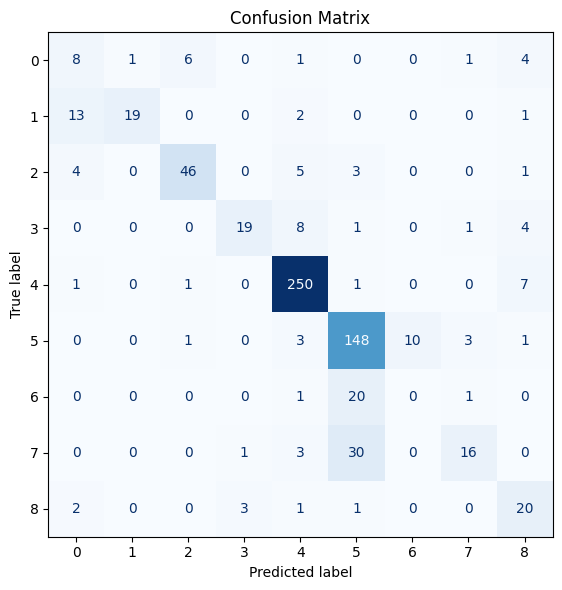

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("[phase=eval] Classification report + confusion matrix")

# Reload best checkpoint for consistent evaluation.
if checkpoint_path.exists():
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.eval()
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(yb.cpu().numpy().tolist())

if len(all_targets) == 0:
    print("[warning] No test samples available for classification report/confusion matrix.")
else:
    labels = np.arange(len(label_encoder.classes_))
    class_names = [str(c) for c in label_encoder.classes_]

    print("[phase=eval] Classification report:")
    print(
        classification_report(
            all_targets,
            all_preds,
            labels=labels,
            target_names=class_names,
            digits=4,
            zero_division=0,
        )
    )

    cm = confusion_matrix(all_targets, all_preds, labels=labels)
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in class_names],
        columns=[f"pred_{c}" for c in class_names],
    )

    print("[phase=eval] Confusion matrix (counts):")
    print(cm_df.to_string())

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [23]:
import pandas as pd
import numpy as np

# Label distribution: train vs val windows
train_labels, train_counts = np.unique(y_train, return_counts=True)
val_labels, val_counts = np.unique(y_val, return_counts=True)

train_dist = dict(zip(label_encoder.inverse_transform(train_labels), train_counts))
val_dist = dict(zip(label_encoder.inverse_transform(val_labels), val_counts))

all_classes = sorted(set(train_dist) | set(val_dist))
print(f"{'Class':<6} {'Train':>8} {'Val':>8} {'Val%':>8}")
print("-" * 34)
for c in all_classes:
    t = train_dist.get(c, 0)
    v = val_dist.get(c, 0)
    pct = v / sum(val_counts) * 100
    print(f"{c:<6} {t:>8} {v:>8} {pct:>7.1f}%")

Class     Train      Val     Val%
----------------------------------
0           989       21     3.1%
1           180       35     5.2%
2           712       59     8.8%
3           295       33     4.9%
4          2528      260    38.6%
5          2748      166    24.7%
6           412       22     3.3%
7           245       50     7.4%
8           587       27     4.0%
